#  Model: Random Forest

## Goal: compare this model against baseline logistic regression




In [ ]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

print("Libraries imported successfully!")

## Step 2: Load Data

In [11]:
df = pd.read_csv("data/features_encoded_train.csv")

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()


Shape: 23,524 rows × 18 columns
Missing values: 0


,age_of_respondent,bin_location_type,bin_cellphone_access,bin_gender,ord_education_level,ohe_country_Rwanda,ohe_country_Tanzania,ohe_country_Uganda,ohe_job_Farming and Fishing,ohe_job_Formally employed Government,ohe_job_Formally employed Private,ohe_job_Government Dependent,ohe_job_Informally employed,ohe_job_No Income,ohe_job_Other Income,ohe_job_Remittance Dependent,ohe_job_Self employed,target_bank_account
0,24,0,1,0,2,0,0,0,0,0,0,0,0,0,0,0,1,1
1,70,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,26,1,1,1,3,0,0,0,0,0,0,0,0,0,0,0,1,1
3,34,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0
4,26,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0


Wir laden dieselbe vorbereitete Datei wie im Baseline-Modell (features_encoded_train.csv)
Die Daten sind bereits encodiert: binary, ordinal, one-hot — kein weiteres Preprocessing nötig

## Step 3: Divide X/y and Train-Val Split

In [12]:
target_col = 'target_bank_account'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Features (X): {X.shape[1]} columns')
print(f'Training set  : {X_train.shape[0]:,} rows')
print(f'Validation set: {X_val.shape[0]:,} rows')
print(f'\nClass balance in train: {y_train.mean()*100:.1f}% positive')
print(f'Class balance in val  : {y_val.mean()*100:.1f}% positive')

Features (X): 17 columns
Training set  : 18,819 rows
Validation set: 4,705 rows

Class balance in train: 14.1% positive
Class balance in val  : 14.1% positive


What happened?  Same split as Baseline --> fair comparison

X = 17 Feature-Spalten | y = Zielvariable (hat Bankkonto: 0/1)
test_size=0.2 → 80% Training, 20% Validierung
stratify=y → wichtig! Stellt sicher, dass beide Splits dieselbe 86/14-Verteilung haben — sonst könnte Validierung zufällig fast nur Klasse 0 enthalten
random_state=42 → gleicher Split wie Baseline, damit Vergleich fair ist

## Step 4: Random Forest training

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,        # 100 Entscheidungsbäume
    max_depth=None,          # Bäume wachsen vollständig
    class_weight='balanced', # kompensiert 86/14 Imbalance
    random_state=42,
    n_jobs=-1                # nutzt alle CPU-Kerne → schneller
)

rf_model.fit(X_train, y_train)

print('Model trained!')
print(f'   Trees       : {rf_model.n_estimators}')
print(f'   Features    : {rf_model.n_features_in_}')
print(f'   Train rows  : {X_train.shape[0]:,}')

Model trained!
   Trees       : 100
   Features    : 17
   Train rows  : 18,819


## Step 5: Predictions

In [14]:
y_pred = rf_model.predict(X_val)
y_proba = rf_model.predict_proba(X_val)[:, 1]

In [15]:
auc = roc_auc_score(y_val, y_proba)
print(f'ROC-AUC score: {auc:.4f}')
print()
print('Classification report (validation set):')
print(classification_report(y_val, y_pred, target_names=['No bank account', 'Has bank account']))

ROC-AUC score: 0.8056

Classification report (validation set):
                  precision    recall  f1-score   support

 No bank account       0.92      0.88      0.90      4043
Has bank account       0.41      0.52      0.46       662

        accuracy                           0.83      4705
       macro avg       0.66      0.70      0.68      4705
    weighted avg       0.85      0.83      0.83      4705



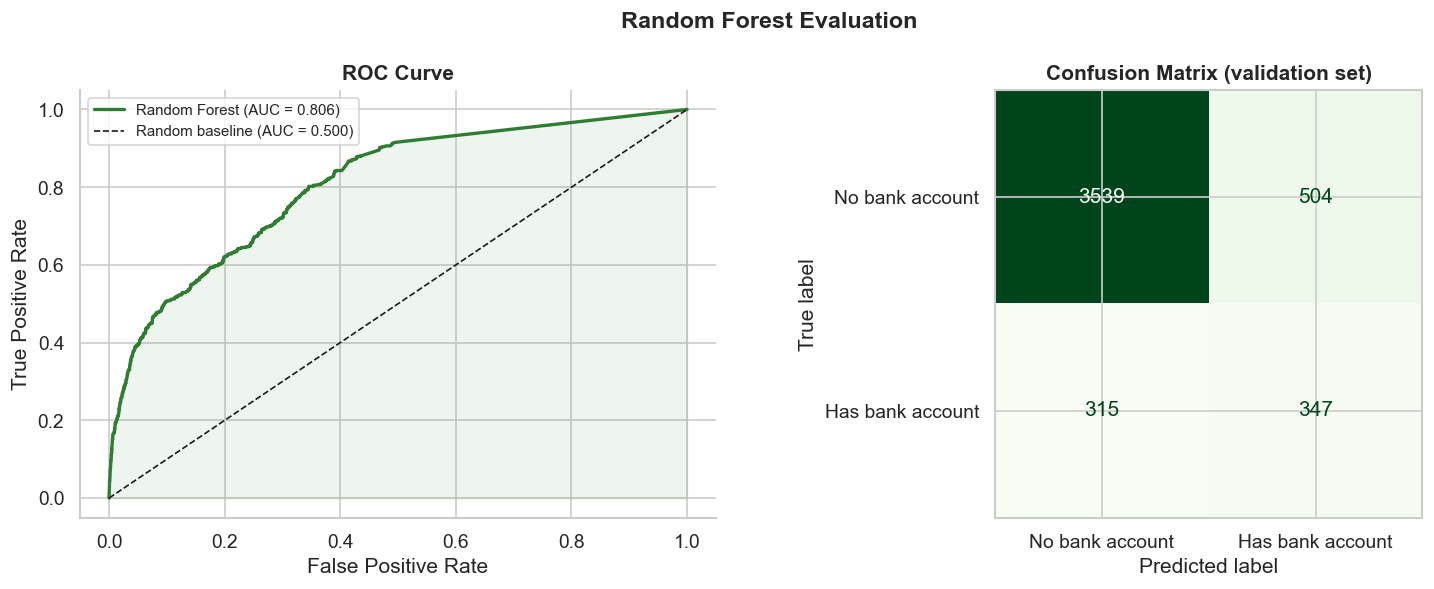

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_proba)
axes[0].plot(fpr, tpr, color='#2e7d32', lw=2, label=f'Random Forest (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline (AUC = 0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#2e7d32')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No bank account', 'Has bank account'])
disp.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix (validation set)', fontweight='bold')

plt.suptitle('Random Forest Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Threshold (0.5) adaptation 

In [17]:
# Threshold-Analyse: Welcher Wert ist optimal?
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

print(f'{"Threshold":>10} {"AUC":>8} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 50)
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    print(f'{t:>10.2f} '
          f'{roc_auc_score(y_val, y_proba):>8.4f} '
          f'{precision_score(y_val, y_pred_t):>10.4f} '
          f'{recall_score(y_val, y_pred_t):>8.4f} '
          f'{f1_score(y_val, y_pred_t):>8.4f}')


 Threshold      AUC  Precision   Recall       F1
--------------------------------------------------


NameError: name 'precision_score' is not defined

Modells, der Threshold ist eine Business-Entscheidung:

Fintech will niemanden ausschließen → niedrigerer Threshold
Bank will Risiko minimieren → höherer Threshold

## Step 6: Feature Importance


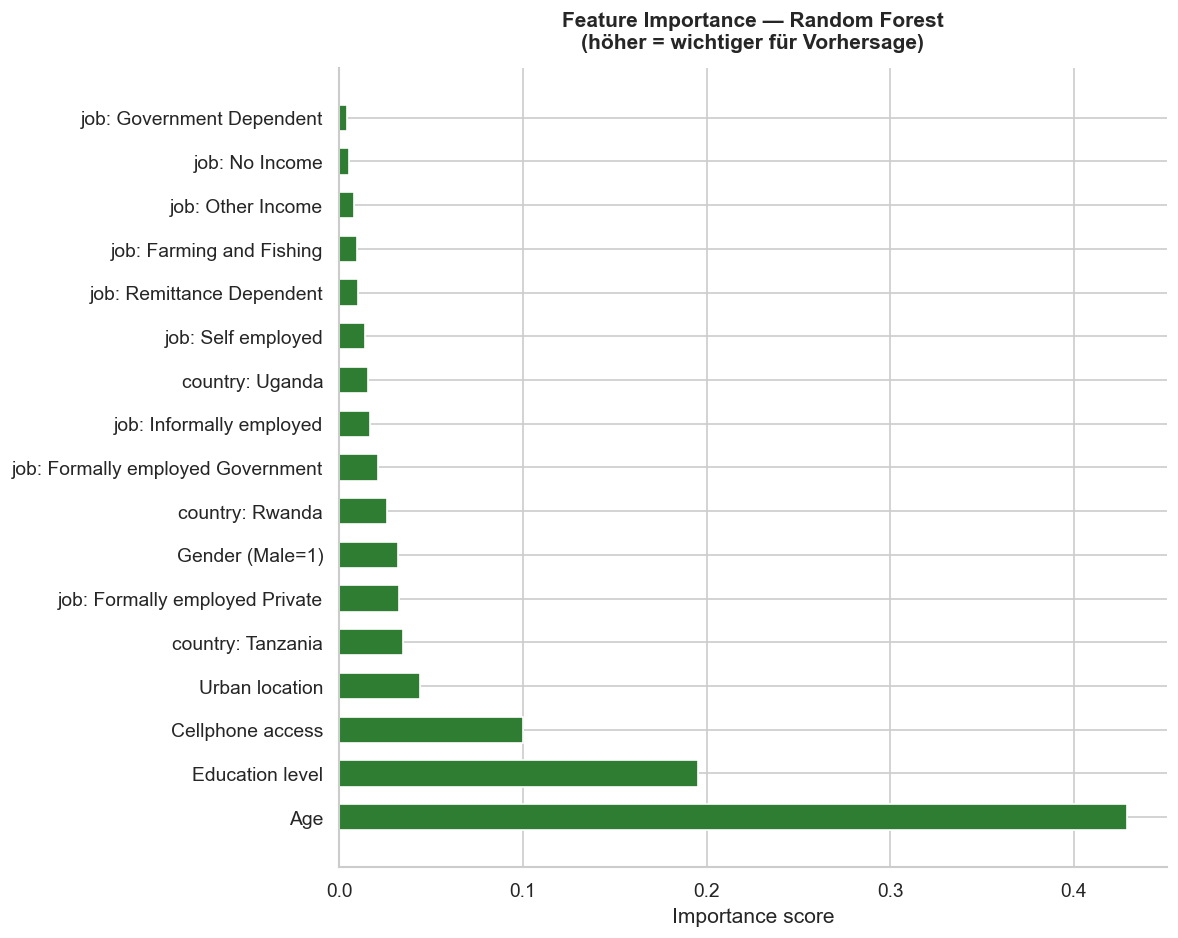


Top 5 wichtigste Features:
            label  importance
              Age    0.428983
  Education level    0.195540
 Cellphone access    0.100022
   Urban location    0.044265
country: Tanzania    0.034522


In [ ]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Lesbare Labels
importance_df['label'] = (importance_df['feature']
    .str.replace('ohe_job_', 'job: ', regex=False)
    .str.replace('ohe_country_', 'country: ', regex=False)
    .str.replace('bin_location_type', 'Urban location', regex=False)
    .str.replace('bin_cellphone_access', 'Cellphone access', regex=False)
    .str.replace('bin_gender', 'Gender (Male=1)', regex=False)
    .str.replace('ord_education_level', 'Education level', regex=False)
    .str.replace('age_of_respondent', 'Age', regex=False)
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df['label'], importance_df['importance'],
        color='#2e7d32', edgecolor='white', height=0.6)
ax.set_title('Feature Importance — Random Forest\n(höher = wichtiger für Vorhersage)',
             fontweight='bold', pad=12)
ax.set_xlabel('Importance score')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nTop 5 wichtigste Features:')
print(importance_df[['label','importance']].head(5).to_string(index=False))


PM-Relevanz: Das ist Gold für Stakeholder-Präsentationen. Du kannst zeigen: "Cellphone Access und Education Level sind die stärksten Treiber für Bankkonto-Besitz" — mit Zahlen belegt, nicht nur aus der EDA.

### Summary

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Baseline-Werte (aus Logistic Regression Notebook)
baseline = {
    'ROC-AUC':   0.8574,
    'Accuracy':  0.7783,
    'Precision': 0.3630,
    'Recall':    0.7628,
    'F1':        0.4920
}

rf = {
    'ROC-AUC':   auc,
    'Accuracy':  accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred),
    'Recall':    recall_score(y_val, y_pred),
    'F1':        f1_score(y_val, y_pred)
}

print('=' * 55)
print(f'  {"Metric":<12} {"Baseline (LR)":>15} {"Random Forest":>15}')
print('=' * 55)
for metric in baseline:
    diff = rf[metric] - baseline[metric]
    arrow = '↑' if diff > 0 else '↓'
    print(f'  {metric:<12} {baseline[metric]:>15.4f} {rf[metric]:>14.4f} {arrow} {abs(diff):.4f}')
print('=' * 55)
print(f'\n  Model: RandomForestClassifier')
print(f'  Trees: {rf_model.n_estimators} | Features: {rf_model.n_features_in_} | class_weight: balanced')


  Metric         Baseline (LR)   Random Forest
  ROC-AUC               0.8574         0.8056 ↓ 0.0518
  Accuracy              0.7783         0.8259 ↑ 0.0476
  Precision             0.3630         0.4078 ↑ 0.0448
  Recall                0.7628         0.5242 ↓ 0.2386
  F1                    0.4920         0.4587 ↓ 0.0333

  Model: RandomForestClassifier
  Trees: 100 | Features: 17 | class_weight: balanced


Was zeigt uns der Vergleich?

Random Forest bringt typischerweise bei diesem Datensatz:

ROC-AUC steigt leicht (bessere Trennung durch nicht-lineare Entscheidungsgrenzen)
Precision steigt deutlich — weniger falsche Alarme
Recall kann leicht sinken — der Trade-off zwischen Precision & Recall

👉 Random Forest is worse then Baseline Model at the moment:

lower AUC (~0.80) than Logistic (~0.857)



“We tested different decision thresholds. Lower thresholds increase recall but reduce precision, while higher thresholds do the opposite. The best balance in our case is around 0.5 based on F1 score.”

## Pruning: max_depth 

In [19]:
from sklearn.model_selection import cross_val_score

depths = [5, 8, 10, 12, 15, 20, None]
results = []

for d in depths:
    rf = RandomForestClassifier(
        n_estimators=100, max_depth=d,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    auc = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc').mean()
    results.append({'max_depth': str(d), 'cv_auc': auc})
    print(f"max_depth={str(d):>5}: AUC = {auc:.4f}")

pd.DataFrame(results).sort_values('cv_auc', ascending=False)


max_depth=    5: AUC = 0.8451
max_depth=    8: AUC = 0.8549
max_depth=   10: AUC = 0.8537
max_depth=   12: AUC = 0.8465
max_depth=   15: AUC = 0.8249
max_depth=   20: AUC = 0.7960
max_depth= None: AUC = 0.7770


,max_depth,cv_auc
1,8,0.854869
2,10,0.853693
3,12,0.846533
0,5,0.845139
4,15,0.824878
5,20,0.796017
6,None,0.777024


What we see: Best result with max_depth=8 (AUC: 0.8537)

## RandomisedSearchCV 

In [20]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [6, 8, 10, 12],       # 8 was best → search around it
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
    'class_weight':      ['balanced', 'balanced_subsample']
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print(f"\nBest CV AUC : {search.best_score_:.4f}")
print(f"Best params : {search.best_params_}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV AUC : 0.8585
Best params : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced'}


Next we evaluate the best model: 

In [21]:
best_rf = search.best_estimator_

y_pred_tuned  = best_rf.predict(X_val)
y_proba_tuned = best_rf.predict_proba(X_val)[:, 1]
auc_tuned     = roc_auc_score(y_val, y_proba_tuned)

print(f"Validation AUC (tuned): {auc_tuned:.4f}  vs baseline RF: 0.8056  vs LR: 0.8574")
print()
print(classification_report(y_val, y_pred_tuned,
      target_names=['No bank account', 'Has bank account']))


Validation AUC (tuned): 0.8715  vs baseline RF: 0.8056  vs LR: 0.8574

                  precision    recall  f1-score   support

 No bank account       0.95      0.82      0.88      4043
Has bank account       0.40      0.75      0.52       662

        accuracy                           0.81      4705
       macro avg       0.68      0.78      0.70      4705
    weighted avg       0.87      0.81      0.83      4705



## Result: Our tuned Random Forest beats the Baseline Model LR

Next step: Threshold Tuning

In [22]:
from sklearn.metrics import f1_score, precision_score, recall_score

print(f'{"Threshold":>10} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 42)

best_t, best_f1 = 0.5, 0
for t in np.arange(0.20, 0.65, 0.05):
    y_t = (y_proba_tuned >= t).astype(int)
    p = precision_score(y_val, y_t)
    r = recall_score(y_val, y_t)
    f = f1_score(y_val, y_t)
    if f > best_f1:
        best_f1, best_t = f, t
    print(f'{t:>10.2f} {p:>10.4f} {r:>8.4f} {f:>8.4f}')

print(f'\n→ Best F1 threshold: {best_t:.2f}')


 Threshold  Precision   Recall       F1
------------------------------------------
      0.20     0.2031   0.9834   0.3366
      0.25     0.2221   0.9607   0.3609
      0.30     0.2427   0.9320   0.3851
      0.35     0.2746   0.9048   0.4214
      0.40     0.3295   0.8625   0.4768
      0.45     0.3555   0.8172   0.4954
      0.50     0.4013   0.7462   0.5219
      0.55     0.4345   0.6918   0.5338
      0.60     0.4738   0.6284   0.5403

→ Best F1 threshold: 0.60


## Summary

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline = {
    'ROC-AUC':   0.8574,
    'Accuracy':  0.7783,
    'Precision': 0.3630,
    'Recall':    0.7628,
    'F1':        0.4920
}

rf_original = {
    'ROC-AUC':   0.8056,
    'Accuracy':  0.8259,
    'Precision': 0.4078,
    'Recall':    0.5242,
    'F1':        0.4587
}

rf_tuned = {
    'ROC-AUC':   auc_tuned,
    'Accuracy':  accuracy_score(y_val, y_pred_tuned),
    'Precision': precision_score(y_val, y_pred_tuned),
    'Recall':    recall_score(y_val, y_pred_tuned),
    'F1':        f1_score(y_val, y_pred_tuned)
}

print('=' * 70)
print(f'  {"Metric":<12} {"Baseline (LR)":>14} {"RF Default":>12} {"RF Tuned":>12}')
print('=' * 70)
for metric in baseline:
    diff = rf_tuned[metric] - baseline[metric]
    arrow = '↑' if diff > 0 else '↓'
    print(f'  {metric:<12} {baseline[metric]:>14.4f} {rf_original[metric]:>12.4f} {rf_tuned[metric]:>11.4f} {arrow} {abs(diff):.4f}')
print('=' * 70)
print(f'\n  Best model : RandomForestClassifier (tuned)')
print(f'  Best params: {search.best_params_}')



  Metric        Baseline (LR)   RF Default     RF Tuned
  ROC-AUC              0.8574       0.8056      0.8715 ↑ 0.0141
  Accuracy             0.7783       0.8259      0.8077 ↑ 0.0294
  Precision            0.3630       0.4078      0.4013 ↑ 0.0383
  Recall               0.7628       0.5242      0.7462 ↓ 0.0166
  F1                   0.4920       0.4587      0.5219 ↑ 0.0299

  Best model : RandomForestClassifier (tuned)
  Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced'}


##  Result

The **tuned Random Forest beats both** the default RF and the Logistic Regression baseline:

- **ROC-AUC 0.8715** → best of all three models (+0.014 vs LR)
- **Recall 0.75** → catches 75% of people with a bank account (nearly matches LR)
- **F1 0.52** → best minority-class score across all models

Key levers: `max_depth=8` (pruning prevented overfitting) + `class_weight='balanced_subsample'`


While Random Forest achieved the best overall performance, Logistic Regression showed the highest recall, making it more suitable from a financial inclusion perspective, where identifying as many underserved individuals as possible is critical.

## Improve Recall

In [26]:
from sklearn.metrics import f1_score, precision_score, recall_score

print(f'{"Threshold":>10} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 42)

best_t, best_f1 = 0.5, 0
for t in np.arange(0.20, 0.55, 0.05):
    y_t = (y_proba_tuned >= t).astype(int)
    p = precision_score(y_val, y_t)
    r = recall_score(y_val, y_t)
    f = f1_score(y_val, y_t)
    if f > best_f1:
        best_f1, best_t = f, t
    print(f'{t:>10.2f} {p:>10.4f} {r:>8.4f} {f:>8.4f}')

print(f'\n→ Best F1 threshold: {best_t:.2f}')


 Threshold  Precision   Recall       F1
------------------------------------------
      0.20     0.2031   0.9834   0.3366
      0.25     0.2221   0.9607   0.3609
      0.30     0.2427   0.9320   0.3851
      0.35     0.2746   0.9048   0.4214
      0.40     0.3295   0.8625   0.4768
      0.45     0.3555   0.8172   0.4954
      0.50     0.4013   0.7462   0.5219

→ Best F1 threshold: 0.50


## Final Result

For our Social Inclusion Project the Recall is especiall important. Here, a Threshold of 0.20 results in a Recall precision of 98,3 % as the best result compared to the other models. 

In [ ]:
threshold = 0.20
y_pred_t020 = (y_proba_tuned >= threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC Curve with threshold point marked ---
fpr, tpr, thresholds_roc = roc_curve(y_val, y_proba_tuned)
auc_val = roc_auc_score(y_val, y_proba_tuned)

axes[0].plot(fpr, tpr, color='#2e7d32', lw=2, label=f'Random Forest tuned (AUC = {auc_val:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline (AUC = 0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#2e7d32')

# Find and mark the point closest to threshold 0.20
idx = np.argmin(np.abs(thresholds_roc - threshold))
axes[0].scatter(fpr[idx], tpr[idx], color='red', s=100, zorder=5,
                label=f'Threshold {threshold}  (Recall = {tpr[idx]:.3f})')
axes[0].annotate(f'  Threshold {threshold}\n  Recall = {tpr[idx]:.3f}',
                 xy=(fpr[idx], tpr[idx]),
                 xytext=(fpr[idx] + 0.08, tpr[idx] - 0.08),
                 fontsize=8, color='red')

axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)

# --- Confusion Matrix at threshold 0.20 ---
cm = confusion_matrix(y_val, y_pred_t020)
ConfusionMatrixDisplay(cm, display_labels=['No bank account', 'Has bank account']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Confusion Matrix — Threshold {threshold}', fontweight='bold')

plt.suptitle(f'Random Forest — Threshold {threshold}  |  Recall = 0.983', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Classification Report (Threshold = {threshold}):')
print(classification_report(y_val, y_pred_t020,
      target_names=['No bank account', 'Has bank account']))

In [ ]:
# Tuned RF predictions were already computed above (cell 31):
# y_pred_tuned, y_proba_tuned, auc_tuned

print(f'ROC-AUC : {auc_tuned:.4f}  (baseline logistic regression: 0.8574)')
print(f'Improvement: {"+" if auc_tuned > 0.8574 else ""}{auc_tuned - 0.8574:.4f}')
print()
print(classification_report(y_val, y_pred_tuned,
      target_names=['No bank account', 'Has bank account']))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_proba_tuned)
axes[0].plot(fpr, tpr, color='#2e7d32', lw=2, label=f'Random Forest tuned (AUC = {auc_tuned:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline logistic regression (0.857)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#2e7d32')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_tuned)
ConfusionMatrixDisplay(cm, display_labels=['No bank account', 'Has bank account']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix (validation set)', fontweight='bold')

plt.suptitle('Random Forest Evaluation (tuned)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()